# Model Evaluation — Comparative Analysis Notebook

This notebook loads the per-scenario evaluation results for **Model A (GPT-5.4-mini)** and **Model B (Qwen3-8B via Ollama)** from `evaluation/results/`, computes aggregate metric averages, and generates two comparison plots:

1. **Per-scenario composite score** — composite score for each of the 10 test scenarios, side by side.
2. **Aggregate metric comparison** — average Fact Recall, Tone Adherence, Structural Completeness, and Composite Score across all scenarios.

Both plots are saved as PNGs to `evaluation/results/plots` for inclusion in the final report.|

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load both models' per-scenario results directly from the eval CSVs
model_a_df = pd.read_csv("results/model_a_results.csv")
model_b_df = pd.read_csv("results/model_b_results.csv")

print(f"Model A: {len(model_a_df)} scenarios loaded")
print(f"Model B: {len(model_b_df)} scenarios loaded")

model_a_df[["scenario_id", "fact_recall_score", "tone_adherence_score", "structural_score", "composite_score"]]

Model A: 10 scenarios loaded
Model B: 10 scenarios loaded


,scenario_id,fact_recall_score,tone_adherence_score,structural_score,composite_score
0,1,0.467,1.00,1.0,0.822
1,2,0.553,0.75,1.0,0.768
2,3,0.489,1.00,1.0,0.830
3,4,0.642,1.00,0.6,0.747
4,5,0.457,1.00,1.0,0.819
5,6,0.555,0.75,1.0,0.768
6,7,0.598,1.00,1.0,0.866
7,8,0.531,0.75,1.0,0.760
8,9,0.447,1.00,0.8,0.749
9,10,0.454,1.00,0.8,0.751


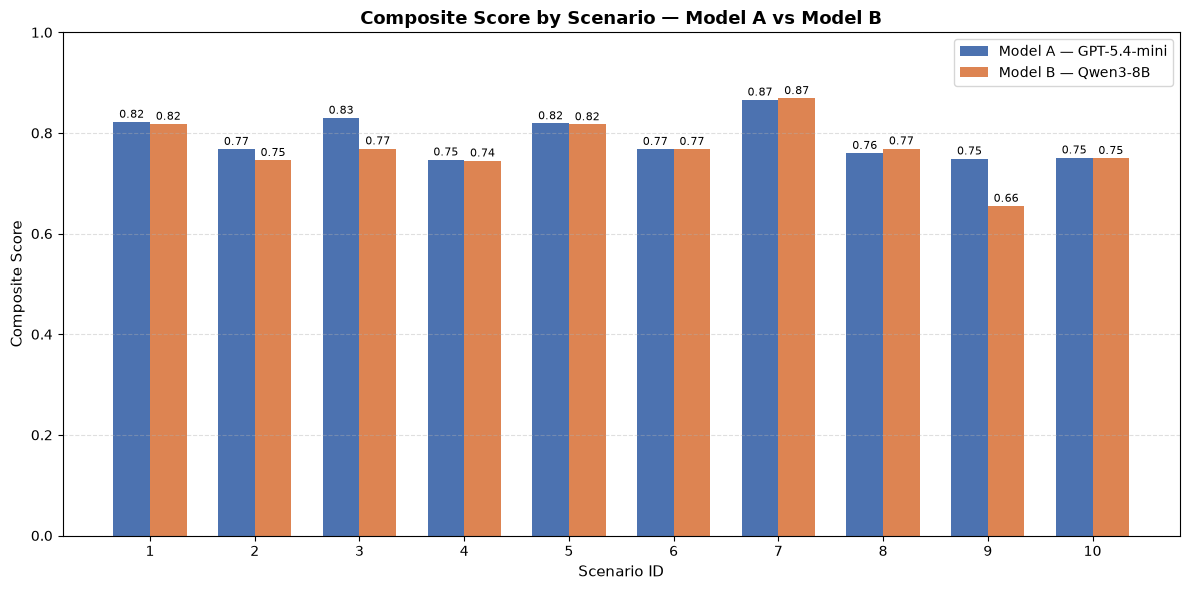

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

scenario_ids = model_a_df["scenario_id"].astype(str)
x = np.arange(len(scenario_ids))
bar_width = 0.35

bars_a = ax.bar(x - bar_width/2, model_a_df["composite_score"], bar_width,
                 label="Model A — GPT-5.4-mini", color="#4C72B0")
bars_b = ax.bar(x + bar_width/2, model_b_df["composite_score"], bar_width,
                 label="Model B — Qwen3-8B", color="#DD8452")

ax.set_xlabel("Scenario ID", fontsize=11)
ax.set_ylabel("Composite Score", fontsize=11)
ax.set_title("Composite Score by Scenario — Model A vs Model B", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(scenario_ids)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Annotate bar values for readability
for bars in (bars_a, bars_b):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.2f}", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("results/plots/plot_per_scenario_composite.png", dpi=200, bbox_inches="tight")
plt.show()

In [7]:
metrics = ["fact_recall_score", "tone_adherence_score", "structural_score", "composite_score"]

model_a_avg = model_a_df[metrics].mean()
model_b_avg = model_b_df[metrics].mean()

summary_df = pd.DataFrame({
    "Model A — GPT-5.4-mini": model_a_avg,
    "Model B — Qwen3-8B (Ollama)": model_b_avg,
})
summary_df.index = ["Fact Recall", "Tone Adherence", "Structural Completeness", "Composite Score"]
summary_df.round(3)

,Model A — GPT-5.4-mini,Model B — Qwen3-8B (Ollama)
Fact Recall,0.519,0.517
Tone Adherence,0.925,0.875
Structural Completeness,0.920,0.920
Composite Score,0.788,0.771


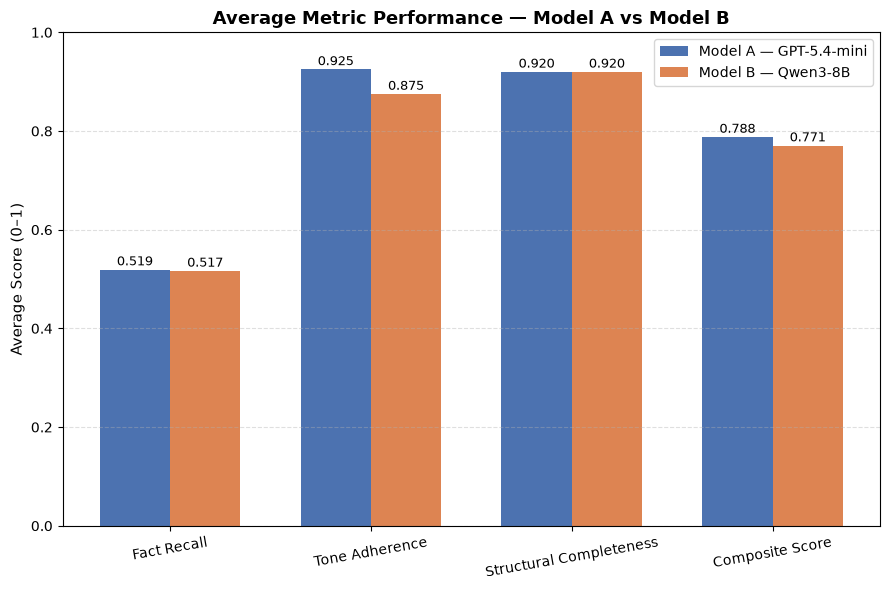

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

metric_labels = summary_df.index.tolist()
x = np.arange(len(metric_labels))
bar_width = 0.35

bars_a = ax.bar(x - bar_width/2, summary_df["Model A — GPT-5.4-mini"], bar_width,
                 label="Model A — GPT-5.4-mini", color="#4C72B0")
bars_b = ax.bar(x + bar_width/2, summary_df["Model B — Qwen3-8B (Ollama)"], bar_width,
                 label="Model B — Qwen3-8B", color="#DD8452")

ax.set_ylabel("Average Score (0–1)", fontsize=11)
ax.set_title("Average Metric Performance — Model A vs Model B", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, rotation=10)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

for bars in (bars_a, bars_b):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("results/plots/plot_aggregate_metrics.png", dpi=200, bbox_inches="tight")
plt.show()